## Data Cleaning Steps

### 1. Check and Handle Missing Values

In [ ]:
import pandas as pd

df = pd.read_csv('/content/telecom_churn_clean.csv')
print('Missing values before cleaning:')
print(df.isnull().sum())

Missing values before cleaning:
Unnamed: 0                0
account_length            0
area_code                 0
international_plan        0
voice_mail_plan           0
number_vmail_messages     0
total_day_minutes         0
total_day_calls           0
total_day_charge          0
total_eve_minutes         0
total_eve_calls           0
total_eve_charge          0
total_night_minutes       0
total_night_calls         0
total_night_charge        0
total_intl_minutes        0
total_intl_calls          0
total_intl_charge         0
customer_service_calls    0
churn                     0
dtype: int64


In [ ]:
# The 'TotalCharges' column is not present in this dataset (`telecom_churn_clean.csv`).
# Also, df.isnull().sum() shows no missing values, so no imputation is needed.

### 2. Check for Duplicates

In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"DataFrame shape after dropping duplicates: {df.shape}")

Number of duplicate rows: 0


### 3. Handle `customerID` Column

In [ ]:
# The 'customerID' column is not present in this dataset (`telecom_churn_clean.csv`).

### 4. Encode Categorical Features

In [ ]:
# The binary categorical columns specified ('gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling')
# are not present in this dataset (`telecom_churn_clean.csv`).
# 'international_plan', 'voice_mail_plan', and 'churn' are already in 0/1 format.

In [ ]:
# The multi-level categorical columns specified ('MultipleLines', 'OnlineSecurity', etc.)
# are not present in this dataset (`telecom_churn_clean.csv`), so one-hot encoding is not applicable here.

## Outlier Identification

Outliers can significantly impact model performance. We will identify outliers in the numerical features using the Interquartile Range (IQR) method and visualize them using box plots.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude binary encoded columns that are essentially categorical (0 or 1)
# We'll assume columns with max value 1 are binary and exclude them from continuous outlier detection
numerical_cols_for_outliers = [col for col in numerical_cols if df[col].nunique() > 2]

print(f"Numerical columns selected for outlier detection: {numerical_cols_for_outliers}")

Numerical columns selected for outlier detection: ['Unnamed: 0', 'account_length', 'area_code', 'number_vmail_messages', 'total_day_minutes', 'total_day_calls', 'total_day_charge', 'total_eve_minutes', 'total_eve_calls', 'total_eve_charge', 'total_night_minutes', 'total_night_calls', 'total_night_charge', 'total_intl_minutes', 'total_intl_calls', 'total_intl_charge', 'customer_service_calls']


In [ ]:
outlier_summary = {}

for col in numerical_cols_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)

    if outlier_count > 0:
        outlier_summary[col] = {
            'count': outlier_count,
            'percentage': (outlier_count / len(df)) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }

print("Outlier Summary (IQR Method):")
if outlier_summary:
    for col, info in outlier_summary.items():
        print(f"Column '{col}': {info['count']} outliers ({info['percentage']:.2f}%) outside [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}]")
else:
    print("No significant outliers detected based on IQR in selected numerical columns.")

Outlier Summary (IQR Method):
Column 'account_length': 18 outliers (0.54%) outside [-5.50, 206.50]
Column 'number_vmail_messages': 1 outliers (0.03%) outside [-30.00, 50.00]
Column 'total_day_minutes': 25 outliers (0.75%) outside [34.65, 325.45]
Column 'total_day_calls': 23 outliers (0.69%) outside [46.50, 154.50]
Column 'total_day_charge': 25 outliers (0.75%) outside [5.89, 55.33]
Column 'total_eve_minutes': 24 outliers (0.72%) outside [63.55, 338.35]
Column 'total_eve_calls': 20 outliers (0.60%) outside [46.50, 154.50]
Column 'total_eve_charge': 24 outliers (0.72%) outside [5.40, 28.76]
Column 'total_night_minutes': 30 outliers (0.90%) outside [64.55, 337.75]
Column 'total_night_calls': 22 outliers (0.66%) outside [48.00, 152.00]
Column 'total_night_charge': 30 outliers (0.90%) outside [2.91, 15.20]
Column 'total_intl_minutes': 46 outliers (1.38%) outside [3.10, 17.50]
Column 'total_intl_calls': 78 outliers (2.34%) outside [-1.50, 10.50]
Column 'total_intl_charge': 49 outliers (1.47%

### Visualizing Outliers with Box Plots

Let's visualize the distribution of some key numerical features using box plots to get a clearer picture of any outliers.

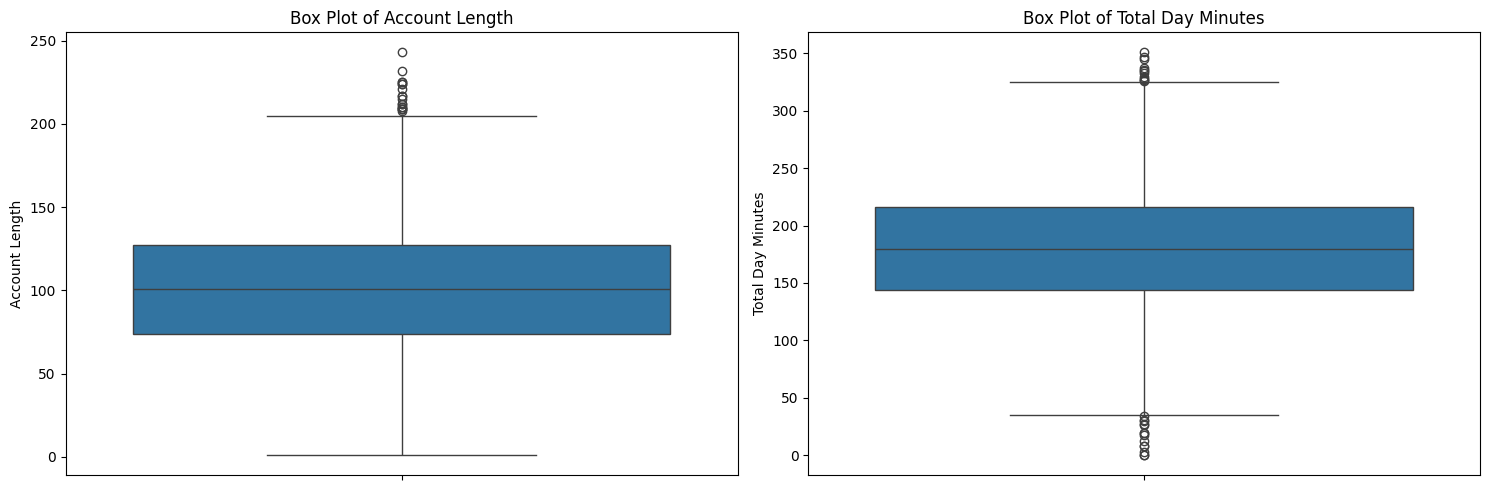

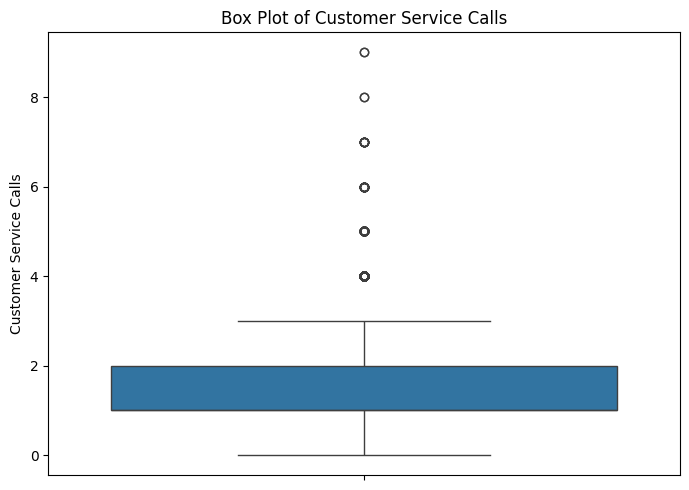

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['account_length'])
plt.title('Box Plot of Account Length')
plt.ylabel('Account Length')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['total_day_minutes'])
plt.title('Box Plot of Total Day Minutes')
plt.ylabel('Total Day Minutes')

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(y=df['customer_service_calls'])
plt.title('Box Plot of Customer Service Calls')
plt.ylabel('Customer Service Calls')

plt.tight_layout()
plt.show()

## Univariate Analysis

### 1. Descriptive Statistics for Numerical Features

In [ ]:
print('Descriptive Statistics for Numerical Features:')
display(df[numerical_cols_for_outliers].describe())

Descriptive Statistics for Numerical Features:


,Unnamed: 0,account_length,area_code,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls
count,3333.00000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,1666.00000,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,962.29855,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,0.00000,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,833.00000,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,1666.00000,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,2499.00000,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,3332.00000,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


### 2. Distribution of Numerical Features (Histograms and KDE plots)

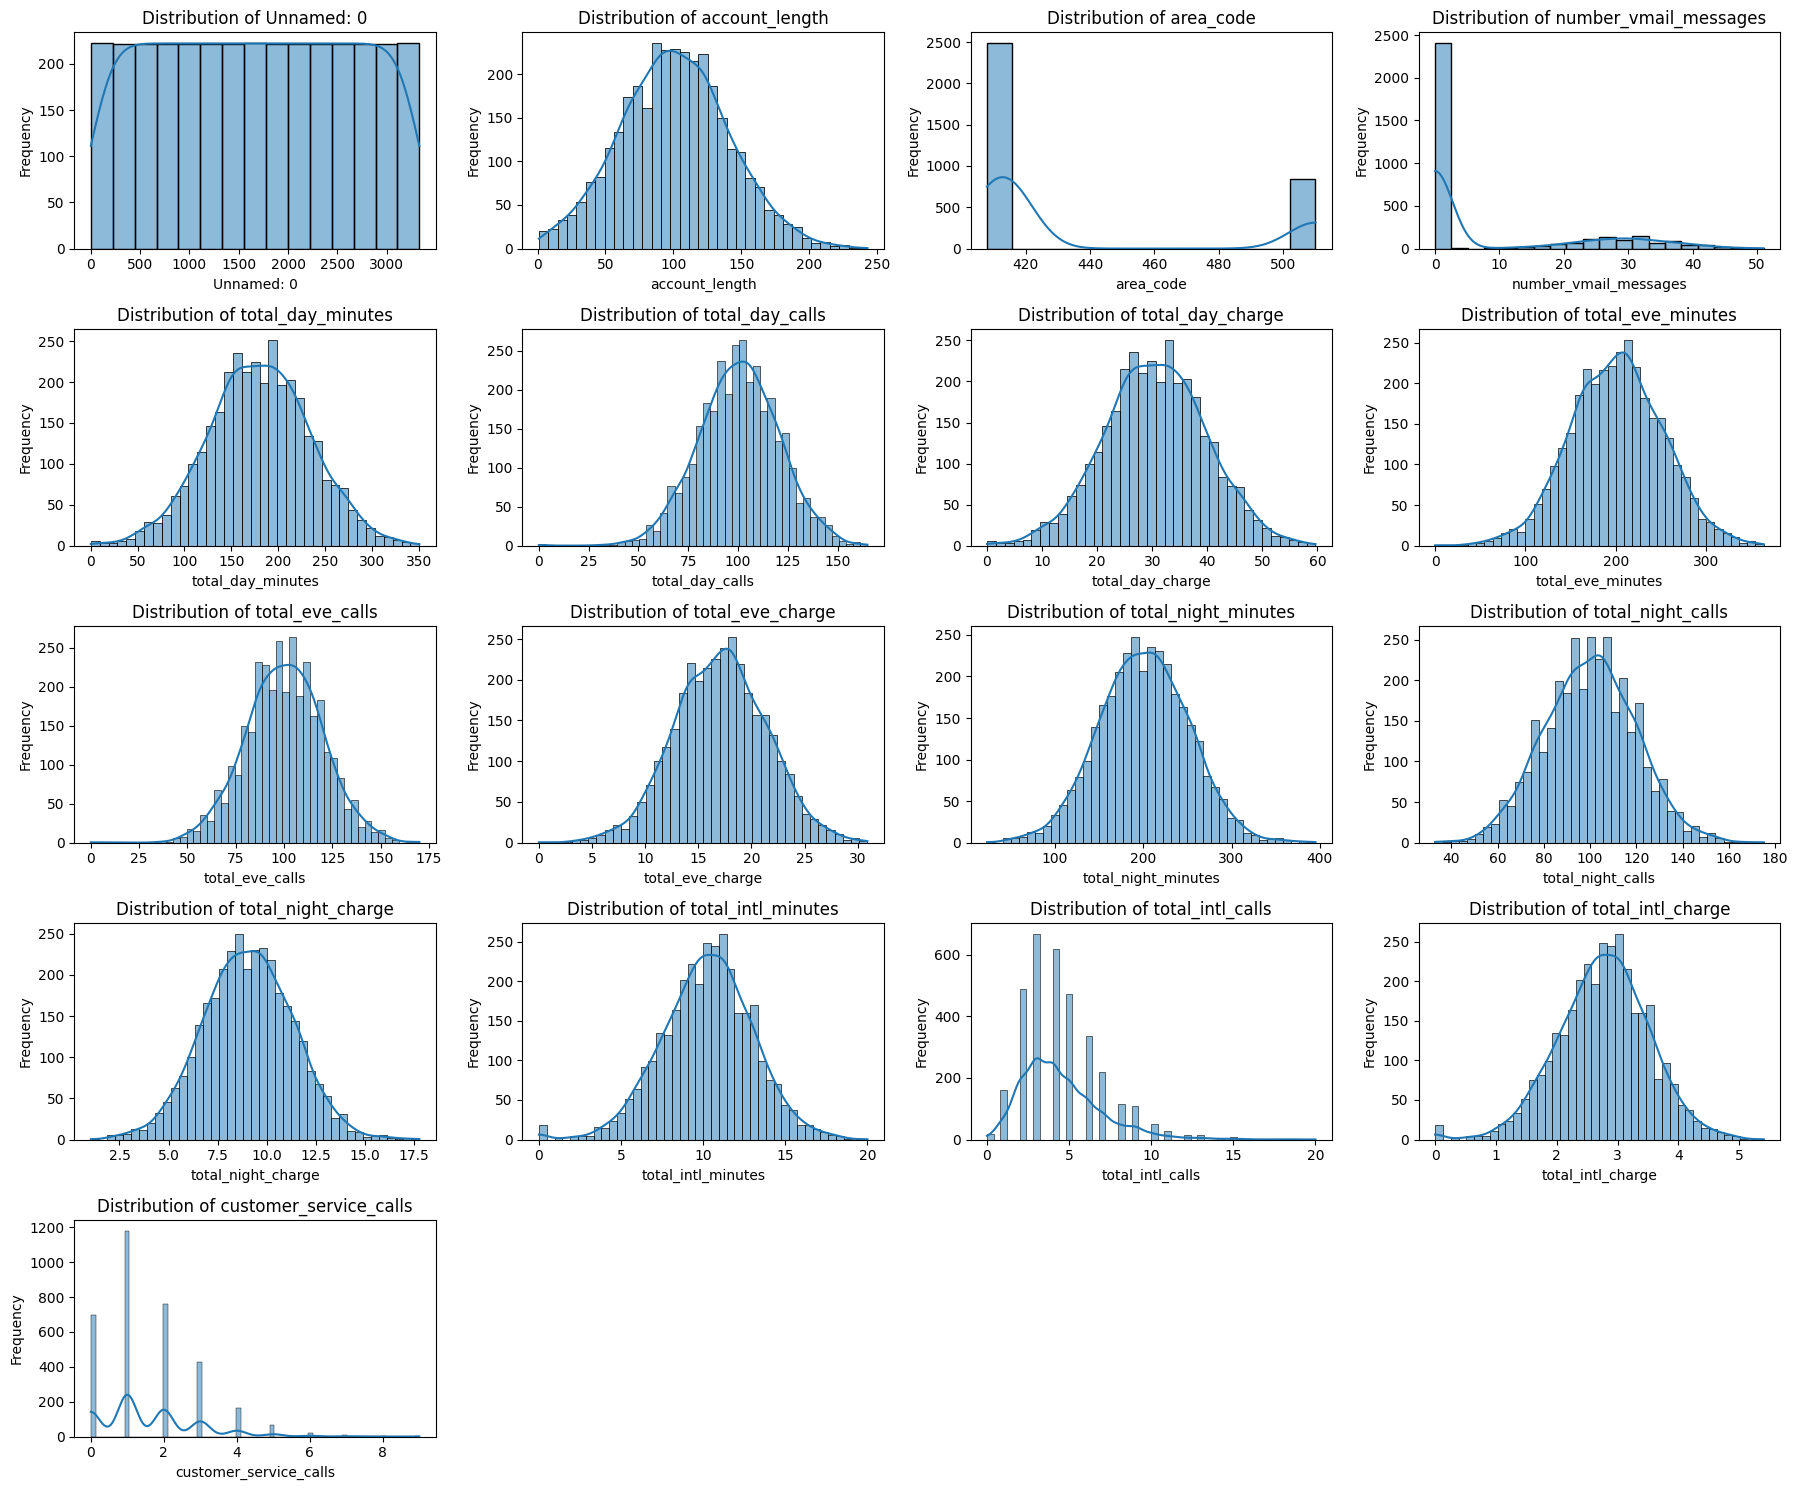

In [ ]:
plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(5, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 3. Distribution of Categorical Features (if any)

Categorical-like columns for univariate analysis: ['international_plan', 'voice_mail_plan', 'churn']


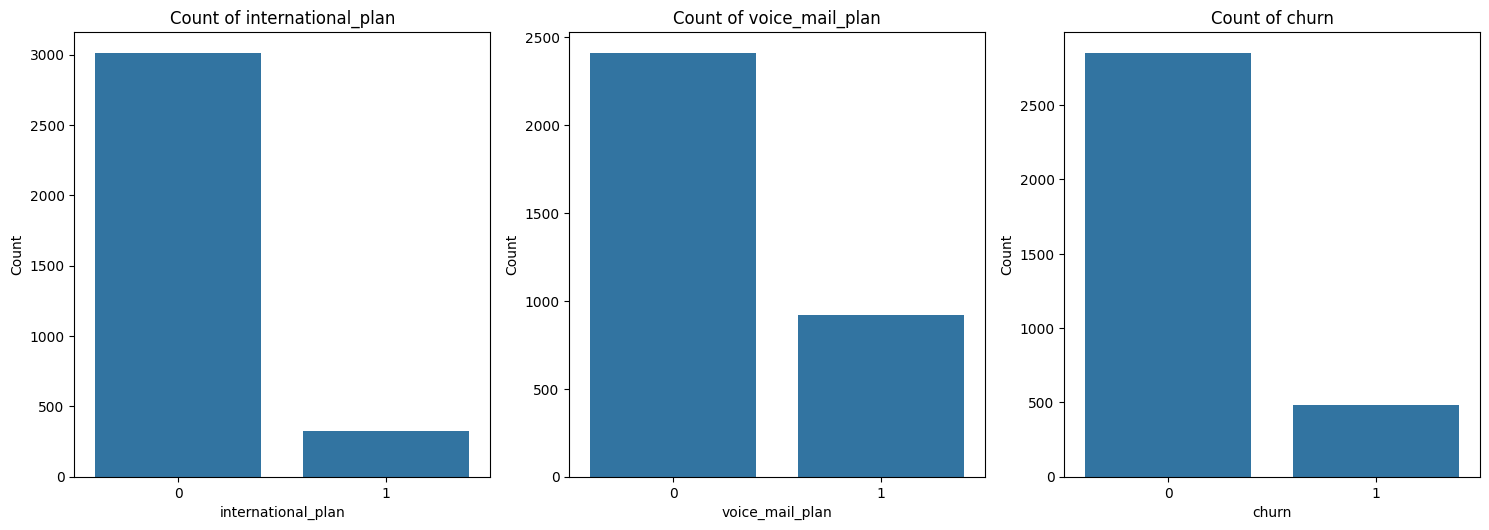

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Also consider binary numerical columns as categorical for count plots
binary_numerical_cols = [col for col in df.select_dtypes(include=np.number).columns if df[col].nunique() <= 2 and col not in ['Unnamed: 0', 'area_code']]

all_categorical_like_cols = categorical_cols + binary_numerical_cols

if all_categorical_like_cols:
    print('Categorical-like columns for univariate analysis:', all_categorical_like_cols)
    plt.figure(figsize=(15, 5 * (len(all_categorical_like_cols) // 3 + 1)))
    for i, col in enumerate(all_categorical_like_cols):
        plt.subplot(len(all_categorical_like_cols) // 3 + 1, 3, i + 1)
        sns.countplot(x=df[col])
        plt.title(f'Count of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('No suitable categorical or binary numerical columns found for count plots.')

## Bivariate Analysis

### 1. Categorical Features vs. Churn

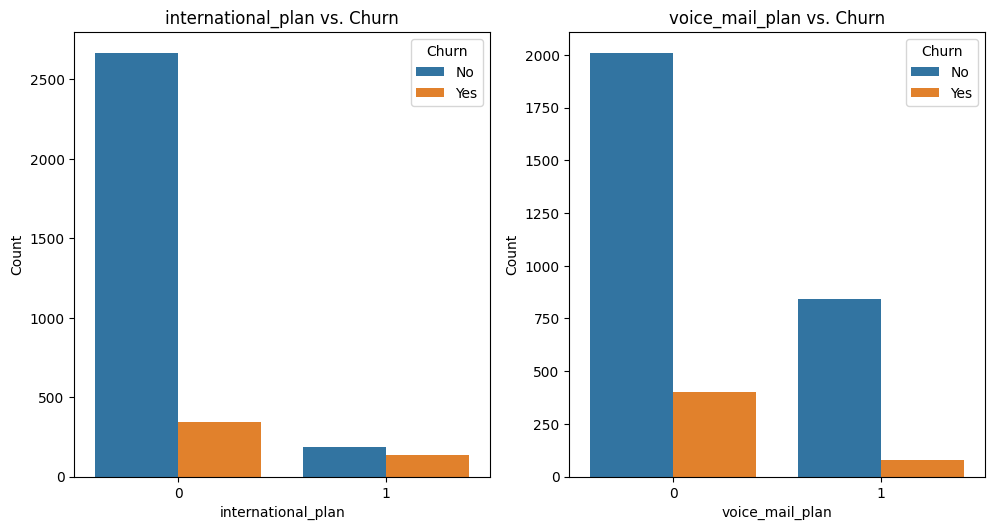

In [ ]:
if all_categorical_like_cols and 'churn' in df.columns:
    plt.figure(figsize=(15, 5 * (len(all_categorical_like_cols) // 3 + 1)))
    plot_index = 1
    for col in all_categorical_like_cols:
        if col != 'churn': # Don't plot churn against itself
            plt.subplot(len(all_categorical_like_cols) // 3 + 1, 3, plot_index)
            sns.countplot(data=df, x=col, hue='churn')
            plt.title(f'{col} vs. Churn')
            plt.xlabel(col)
            plt.ylabel('Count')
            plt.legend(title='Churn', labels=['No', 'Yes'])
            plot_index += 1
    plt.tight_layout()
    plt.show()
elif 'churn' not in df.columns:
    print("The 'churn' column is not available for bivariate analysis with other categorical features.")
else:
    print('No suitable categorical or binary numerical columns found for bivariate count plots.')

### 2. Numerical Features vs. Churn

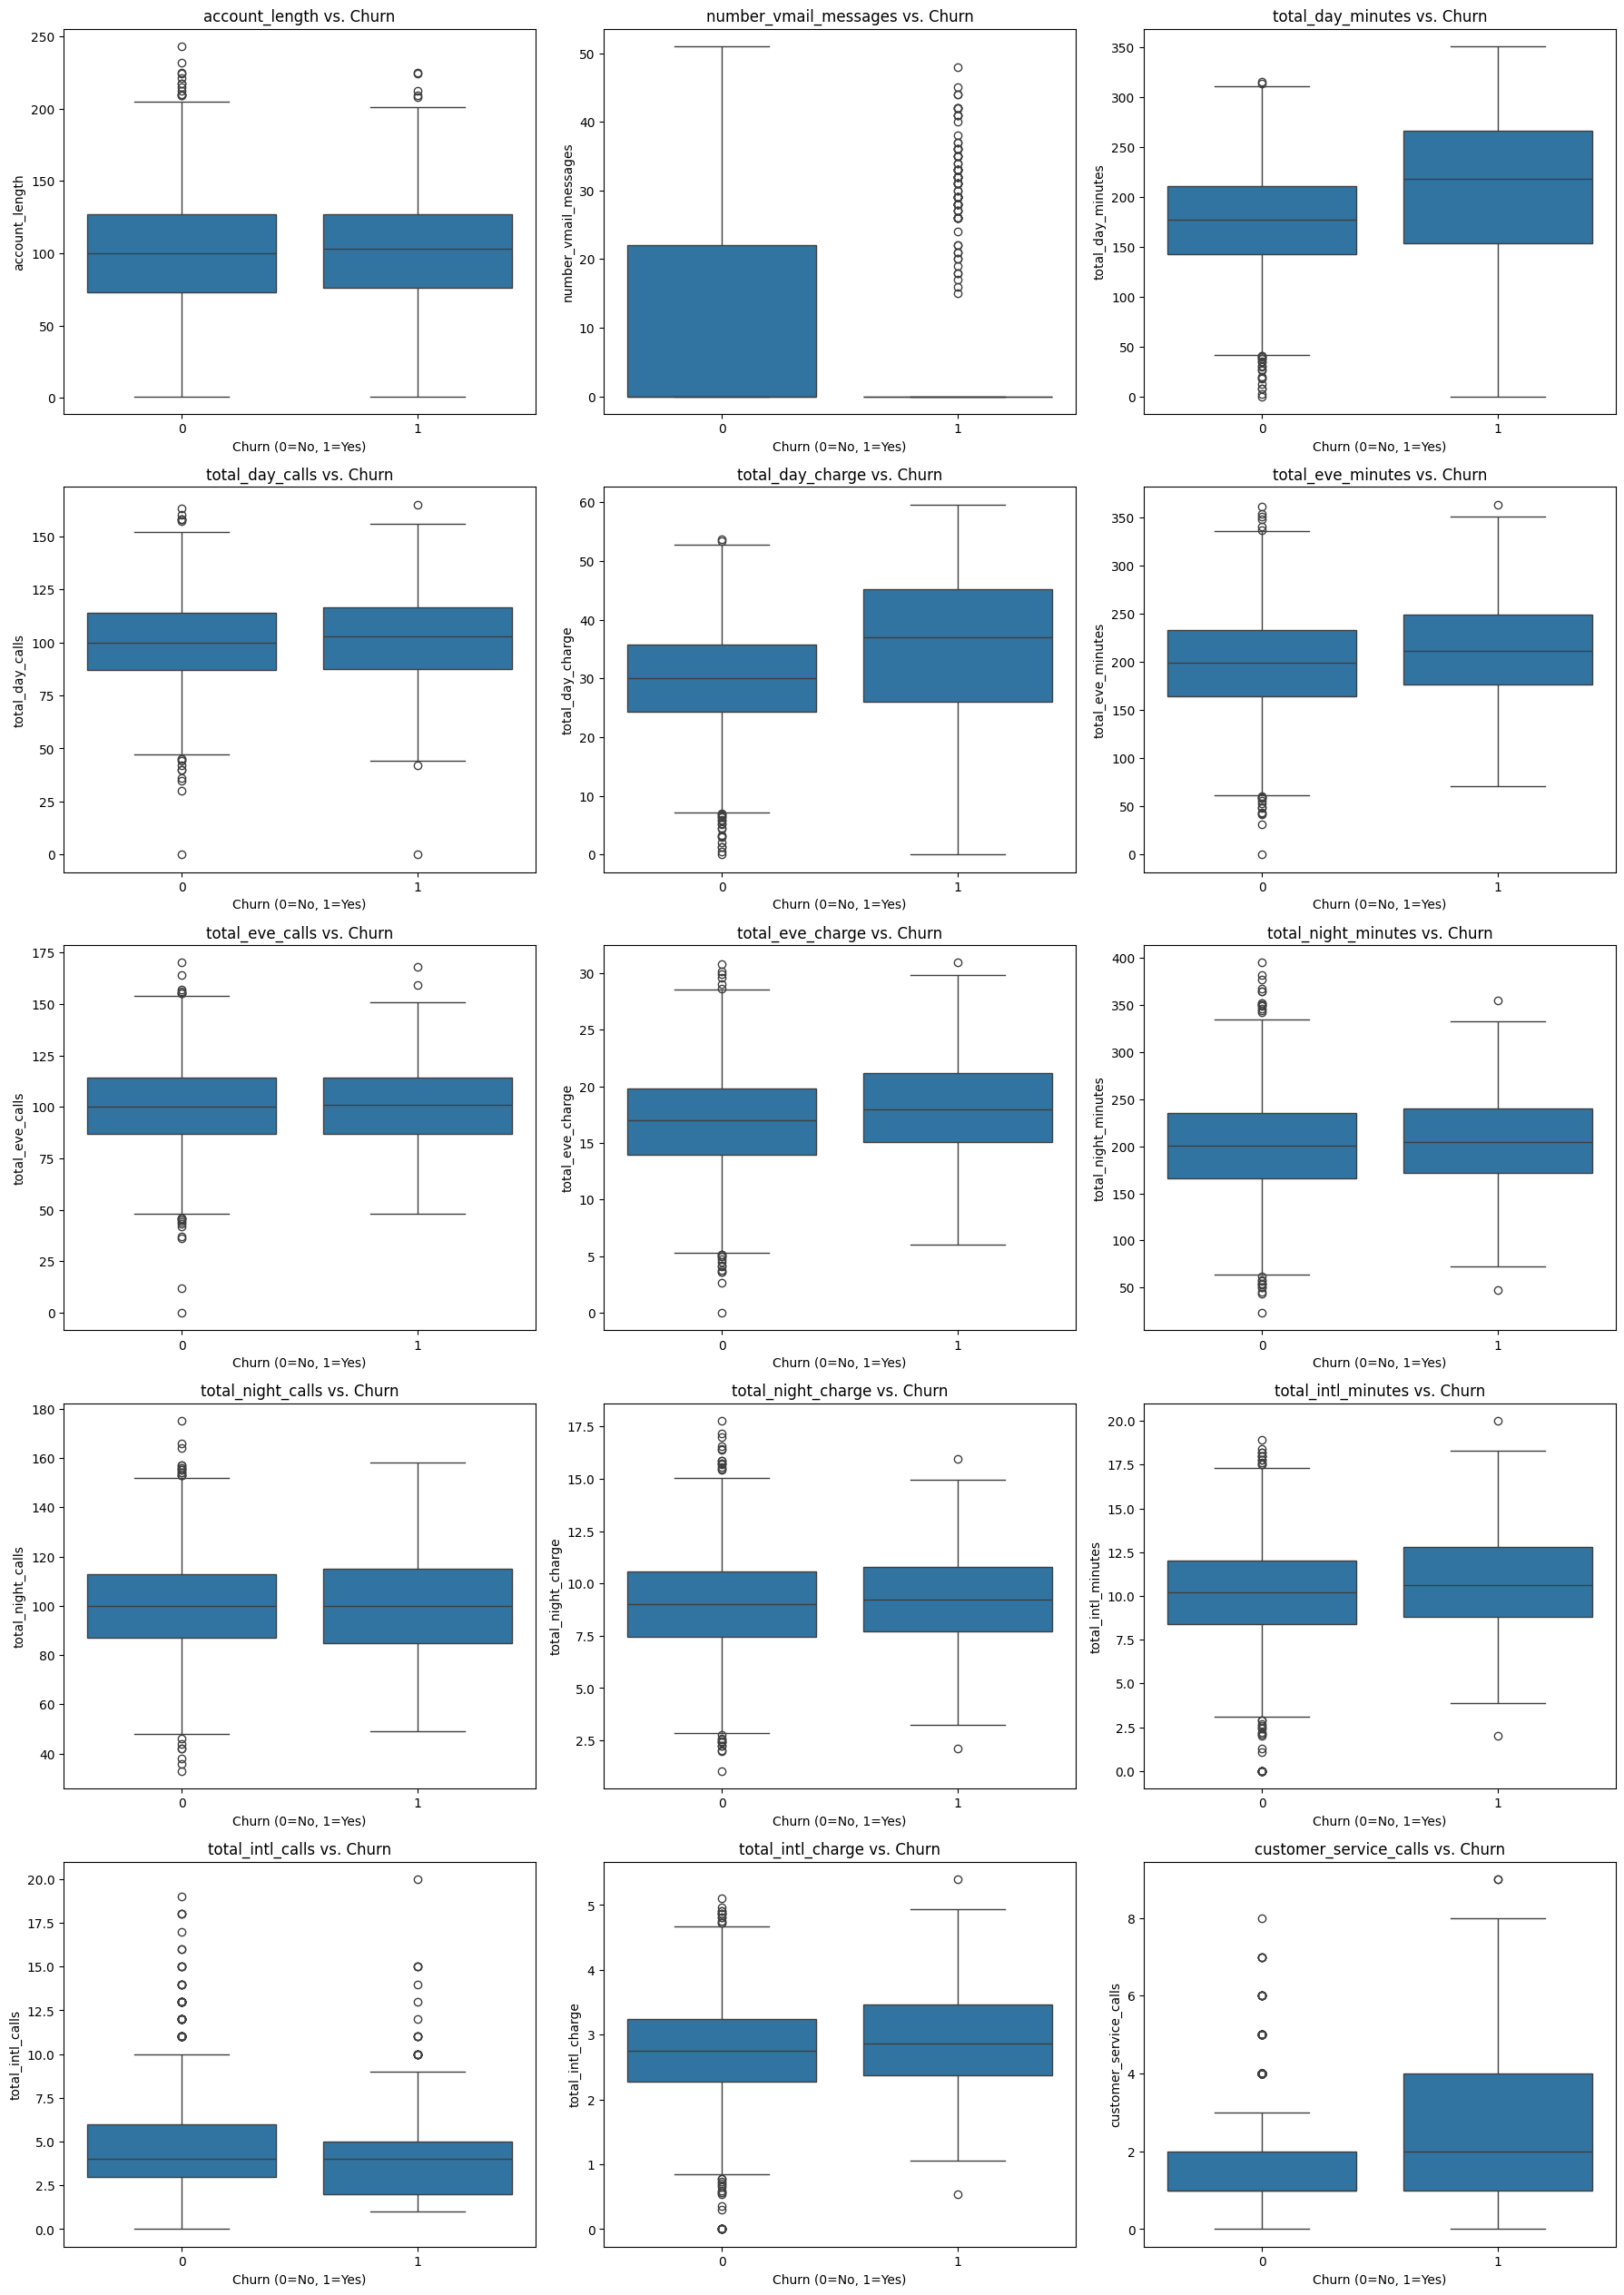

In [ ]:
if numerical_cols_for_outliers and 'churn' in df.columns:
    plt.figure(figsize=(18, 5 * (len(numerical_cols_for_outliers) // 3 + 1)))
    plot_index = 1
    for col in numerical_cols_for_outliers:
        if col != 'Unnamed: 0' and col != 'area_code': # Exclude ID and area_code for this type of plot
            plt.subplot(len(numerical_cols_for_outliers) // 3 + 1, 3, plot_index)
            sns.boxplot(data=df, x='churn', y=col)
            plt.title(f'{col} vs. Churn')
            plt.xlabel('Churn (0=No, 1=Yes)')
            plt.ylabel(col)
            plot_index += 1
    plt.tight_layout()
    plt.show()
elif 'churn' not in df.columns:
    print("The 'churn' column is not available for bivariate analysis with numerical features.")
else:
    print('No suitable numerical columns found for bivariate box plots.')

### 3. Correlation Matrix of Numerical Features

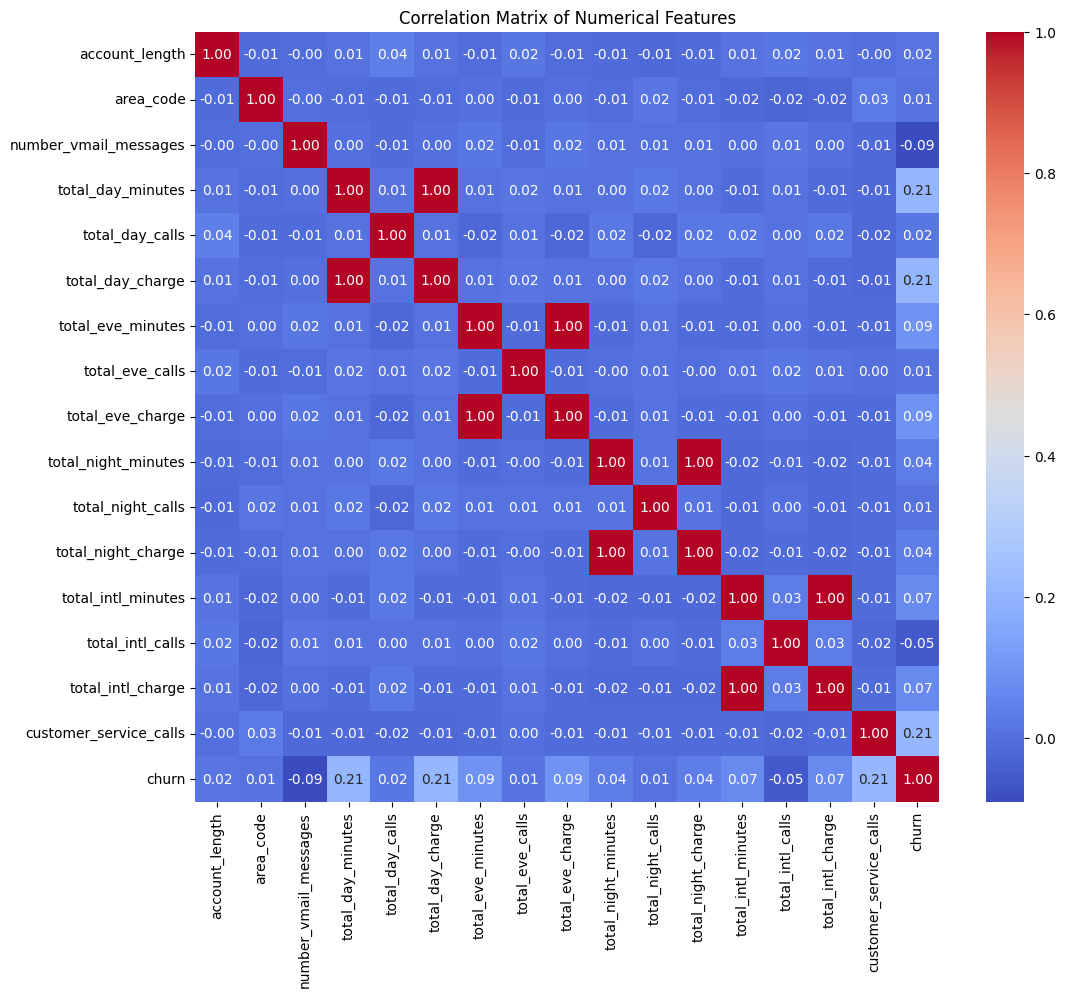

In [ ]:
if numerical_cols_for_outliers:
    # Include 'churn' in the correlation matrix if it's a numerical column
    cols_for_corr = [col for col in numerical_cols_for_outliers if col != 'Unnamed: 0']
    if 'churn' in df.columns:
        cols_for_corr.append('churn')

    correlation_matrix = df[cols_for_corr].corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Matrix of Numerical Features')
    plt.show()
else:
    print('No suitable numerical columns found to compute correlation matrix.')